Logo file not found, creating a placeholder.


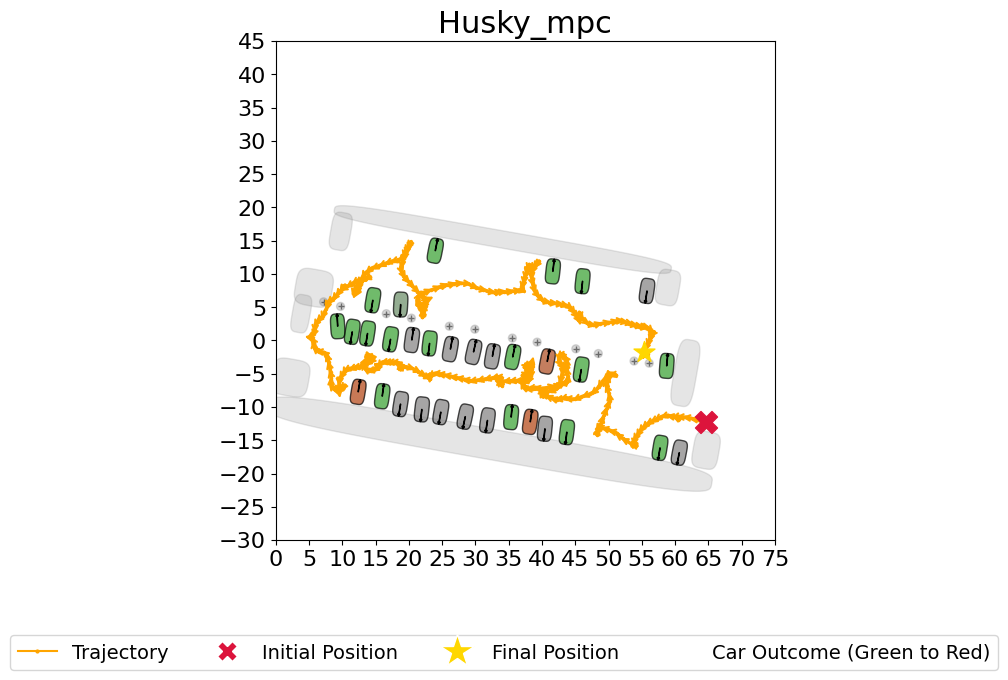

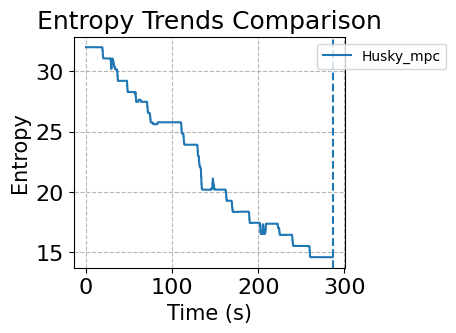

In [4]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import seaborn as sns
from PIL import Image
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.ticker import MultipleLocator
import matplotlib.patches as patches
from matplotlib.legend_handler import HandlerBase
import io

# ==========================================
# 1. SETUP PALETTE E COLORI (Dal Notebook originale)
# ==========================================
try:
    logo_arr = mpimg.imread("/home/pantheon/drea/neural_mpc/ros/src/nmpc_ros/results/sun_orientation.png")
except:
    print("Logo file not found, creating a placeholder.")
    logo_arr = np.zeros((10, 10, 4)) 

paired_palette = sns.color_palette("Paired")
dark_paired_palette = sns.color_palette("dark")

# Colormap per le auto (Verde, Grigio, Rosso) in base all'esito (lambda)
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap", [paired_palette[3], (0.5, 0.5, 0.5), dark_paired_palette[1]]
)

# ==========================================
# 2. PARAMETRI GEOMETRICI (Dal file plot_vincoli)
# ==========================================
safe_radius_pole = 0.6
poles_pos = np.array([
    [7.1905, 5.7978], [9.7331, 5.1122], [16.6093, 4.0214],
    [20.3781, 3.3552], [26.0805, 2.1324], [29.9115, 1.6864],
    [35.5549, 0.3543], [39.2697, -0.2548], [45.0900, -1.2590],
    [48.4675, -1.9691], [53.8411, -3.1006], [56.1188, -3.4193],
], dtype=np.float32)

margin_f = 0.5
flowerbeds_pos = np.array([
    [2.1879, -5.5748, 4.6071, 4.5434, -0.175],
    [64.6609, -16.5047, 2.8938, 4.5661, -0.175],
    [32.1876, -15.5858, 66.7007, 3.5897, -0.175],
    [3.8231, 4.0245, 1.6749, 4.7252, -0.175],
    [5.7205, 7.9094, 4.5549, 4.5383, -0.175],
    [61.5571, -4.8938, 2.4004, 9.0567, -0.175],
    [9.7648, 16.3899, 2.0120, 4.6903, -0.175],
    [58.9274, 7.9500, 2.4176, 4.3564, -0.175],
    [34.1108, 15.1653, 50.4020, 1.5882, -0.175],
], dtype=np.float32)

car_length = 3.46 
car_width = 1.62   
margin_x = 0.6    
margin_y = 0.5 
core_safety = 0.8 

# ==========================================
# 3. HANDLERS LEGGENDA E FUNZIONI DI SUPPORTO
# ==========================================
class HandlerGradient(HandlerBase):
    def __init__(self, cmap, num_stripes=64, **kw):
        super().__init__(**kw)
        self.cmap = cmap
        self.num_stripes = num_stripes

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        gradient = np.linspace(0, 1, self.num_stripes)
        colors = self.cmap(gradient)
        stripes = []
        for i in range(self.num_stripes):
            stripe = patches.Rectangle([xdescent + i * width / self.num_stripes, ydescent],
                                     width / self.num_stripes, height,
                                     fc=colors[i], transform=trans, edgecolor='none')
            stripes.append(stripe)
        return stripes

class HandlerImage(HandlerBase):
    def __init__(self, image_arr, zoom=1.0, **kw):
        super().__init__(**kw)
        self.image_arr = image_arr
        self.zoom = zoom

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        imagebox = OffsetImage(self.image_arr, zoom=self.zoom)
        ab = AnnotationBbox(imagebox, (xdescent + 0.5 * width, ydescent + 0.5 * height),
                            frameon=False, xycoords=trans, box_alignment=(0.5, 0.5), pad=0)
        return [ab]

def generate_superellipse(center_x, center_y, a, b, theta, n=4, num_points=200):
    """Genera i punti (x, y) di una superellisse ruotata."""
    t = np.linspace(0, 2 * np.pi, num_points)
    power = 2.0 / n
    x_rel = a * np.sign(np.cos(t)) * (np.abs(np.cos(t)) ** power)
    y_rel = b * np.sign(np.sin(t)) * (np.abs(np.sin(t)) ** power)
    dx = x_rel * np.cos(theta) - y_rel * np.sin(theta)
    dy = x_rel * np.sin(theta) + y_rel * np.cos(theta)
    return center_x + dx, center_y + dy

def get_latest_csv(mode, directory, suffix="plot_data.csv"):
    pattern = os.path.join(directory, f"{mode}*{suffix}")
    files = glob.glob(pattern)
    if not files:
        return None
    return max(files, key=os.path.getmtime)

def load_csv_data(csv_path):
    with open(csv_path, 'r') as f:
        first_line = f.readline().strip()
    parts = first_line.split(',')
    if parts[0] == "tree_positions":
        tree_positions_list = [float(x) for x in parts[1:] if x]
        if tree_positions_list:
            num_trees = len(tree_positions_list) // 3
            tree_positions = np.array(tree_positions_list).reshape(num_trees, 3)
        else:
            tree_positions = np.array([]).reshape(0,3)
    else:
        tree_positions = None
    df = pd.read_csv(csv_path, skiprows=2)
    return (
        df["time"].values, df["x"].values, df["y"].values, df["theta"].values,
        df["entropy"].values, df[[col for col in df.columns if col.startswith("lambda_")]].values,
        tree_positions
    )

# ==========================================
# 4. FUNZIONI DI PLOTTING MIGLIORATE
# ==========================================
def plot_trajectory_subplot(ax, x, y, theta, trees, lambda_history, custom_cmap,
                            tree_label_fontsize, legend_fontsize_param,
                            axis_label_fontsize, tick_label_fontsize,
                            subplot_title_fontsize, mode_label_for_title):
    
    # Plot Traiettoria Drone
    ax.plot(x, y, marker='o', color='orange', linewidth=2.5, markersize=1.5, label="Drone Trajectory")
    ax.scatter(x[0], y[0], color='crimson', s=250, marker='X', label="Initial Position", zorder=6)
    ax.scatter(x[-1], y[-1], color='gold', s=250, marker='*', label="Final Position", zorder=6)

    # Plot Vincoli Hard - Pali
    for p in poles_pos:
        circle = patches.Circle((p[0], p[1]), safe_radius_pole, color='gray', alpha=0.3)
        ax.add_patch(circle)
        ax.plot(p[0], p[1], 'k+', markersize=4, alpha=0.5)

    # Plot Vincoli Hard - Aiuole
    for f in flowerbeds_pos:
        fx, fy, flen, fwid, ftheta = f[0], f[1], f[2], f[3], f[4]
        sigma_x_f = (flen / 2.0) + margin_f
        sigma_y_f = (fwid / 2.0) + margin_f
        x_se, y_se = generate_superellipse(fx, fy, sigma_x_f, sigma_y_f, ftheta)
        ax.fill(x_se, y_se, color='gray', alpha=0.2)

    # Plot Auto/Macchine (Trees nel tuo CSV) con Superellissi
    if trees is not None and trees.size > 0:
        for i in range(trees.shape[0]):
            final_lambda = lambda_history[-1, i*2]
            tree_color = custom_cmap(final_lambda)
            
            car_x = trees[i, 0]
            car_y = trees[i, 1]
            car_theta = trees[i, 2]
            
            # Traslazione al centro geometrico
            center_x = car_x - (car_length / 2.0) * np.cos(car_theta)
            center_y = car_y - (car_length / 2.0) * np.sin(car_theta)
            
            sigma_x = (car_length / 2.0) + margin_x
            sigma_y = (car_width / 2.0) + margin_y
            a_hard = sigma_x * core_safety
            b_hard = sigma_y * core_safety
            
            # Disegna la superellisse dell'auto con il colore basato sull'entropia
            x_se, y_se = generate_superellipse(center_x, center_y, a_hard, b_hard, car_theta)
            ax.fill(x_se, y_se, color=tree_color, alpha=0.7, edgecolor='black', zorder=3)
            
            # Disegna l'orientamento dell'auto
            arrow_length = 1.5 
            dx = arrow_length * np.cos(car_theta)
            dy = arrow_length * np.sin(car_theta)
            ax.arrow(center_x, center_y, dx, dy, color='black', width=0.05, head_width=0.4, head_length=0.4, zorder=4)

    # Frecce Direzione Drone
    step = max(1, len(x) // 300)
    for idx_arr in range(0, len(x), step):
        x0, y0, t = x[idx_arr], y[idx_arr], theta[idx_arr]
        x1 = x0 + 1.5 * np.cos(t)
        y1 = y0 + 1.5 * np.sin(t)
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="->", color="orange", linewidth=1.5))

    ax.tick_params(axis='both', labelsize=tick_label_fontsize)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(0, 75)
    ax.set_ylim(-30, 45)
    ax.set_title(mode_label_for_title, fontsize=subplot_title_fontsize)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_major_locator(MultipleLocator(5))

def plot_entropy_subplot(ax, time_history, entropy, label, color, axis_label_fontsize, tick_label_fontsize):
    ax.plot(time_history, entropy, linewidth=1.5, markersize=1.0, label=label, color=color)
    ax.set_xlabel("Time (s)", fontsize=axis_label_fontsize)
    ax.set_ylabel("Entropy", fontsize=axis_label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_label_fontsize)

# ==========================================
# 5. ESECUZIONE (Multi-mode Comparison)
# ==========================================
modes = ["husky_mpc"] 
baselines_dir = "../to_plot"

axis_label_fontsize = 15
tick_label_fontsize = 16
subplot_title_fontsize = 22
legend_fontsize = 14
suptitle_fontsize = 18
tree_label_fontsize = 10

algorithm_labels = {
    "linear": "Linear Path",
    "greedy": "Greedy Approach",
    "mower": "Mower Path",
    "mower_good": "Mower Path - Good View",
    "mower_bad": "Mower Path - Poor View",
    "mpc": "Neural IPP MPC",
}

nrows = 1
ncols = (len(modes) + nrows - 1) // nrows 

fig_traj, axs_traj = plt.subplots(nrows, ncols, figsize=(6 * 1, 6.5 * nrows), squeeze=False)
axs_flat = axs_traj.flatten() 
fig_entropy, ax_entropy = plt.subplots(figsize=(3.5, 3))

colors = sns.color_palette("tab10", len(modes))
any_trees = False

for i, mode in enumerate(modes):
    label = algorithm_labels.get(mode, mode.capitalize())
    csv_file = get_latest_csv(mode, baselines_dir)
    if not csv_file:
        print(f"No CSV found for {mode}")
        if i < len(axs_flat):
            axs_flat[i].axis('off')
        continue
    try:
        time_h, x, y, theta, entropy, lambda_h, trees = load_csv_data(csv_file)
        if trees is not None and trees.size > 0:
            any_trees = True
    except Exception as e:
        print(f"Error loading {csv_file}: {e}")
        if i < len(axs_flat):
            axs_flat[i].axis('off')
        continue

    ax_t = axs_flat[i] 
    plot_trajectory_subplot(ax_t, x, y, theta, trees, lambda_h, custom_cmap,
                            tree_label_fontsize, legend_fontsize,
                            axis_label_fontsize, tick_label_fontsize,
                            subplot_title_fontsize, label)
    oim = OffsetImage(logo_arr, zoom=0.075)
    ab = AnnotationBbox(oim, (-0.01, 1.01), xycoords="axes fraction", frameon=False)
    ax_t.add_artist(ab)

    plot_entropy_subplot(ax_entropy, time_h, entropy, label, colors[i],
                         axis_label_fontsize, tick_label_fontsize)
    ax_entropy.axvline(x=time_h[-1], color=colors[i], linestyle='--', linewidth=1.5)

for i in range(len(modes), len(axs_flat)):
    axs_flat[i].axis('off')

# Finalize Trajectory Plot
legend_handles = [
    Line2D([0], [0], color='orange', lw=1.5, marker='o', markersize=2, label='Drone Trajectory'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='crimson', markersize=15, label='Initial Position'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markersize=25, label='Final Position')
]
legend_labels = ['Trajectory', 'Initial Position', 'Final Position']

image_handle = patches.Patch(color='none')
legend_handles.append(image_handle)

handler_map = {
    image_handle: HandlerImage(logo_arr, zoom=0.04) 
}

if any_trees:
    gradient_handle = patches.Patch(color='none')
    legend_handles.append(gradient_handle)
    legend_labels.append('Car Outcome (Green to Red)')
    handler_map[gradient_handle] = HandlerGradient(cmap=custom_cmap)

fig_traj.tight_layout(rect=[0, 0.05, 1, 0.95])
fig_traj.legend(
    handles=legend_handles, 
    labels=legend_labels,
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.1), 
    ncol=5, 
    fontsize=legend_fontsize,
    handler_map=handler_map
)

output_path_traj = os.path.join(baselines_dir, f"thesis_mpc_trajectory_grid.png")
fig_traj.savefig(output_path_traj, format='png', bbox_inches='tight',  dpi=350)

# Finalize Entropy Plot
ax_entropy.set_title("Entropy Trends Comparison", fontsize=suptitle_fontsize)
ax_entropy.legend(loc='upper right',  bbox_to_anchor=(1.4, 1.0))
ax_entropy.grid(True, linestyle='--', alpha=0.9)
output_path_entropy = os.path.join(baselines_dir, f"entropy_comparison.png")
fig_entropy.savefig(output_path_entropy, format='png', bbox_inches='tight', dpi=350)

plt.show()